<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Regressão Linear

Técnica de ML que visa encontrar a relação entre variáveis (atributos e rótulos).

## Equação da reta:

* $y = mx + b$

onde:

* $y$ - valor de y (saída do modelo (valor predito/previsto))

* $x$ - valor de x (entrada do modelo)

* $m$ - inclinação da reta (coeficiente linear) (peso)

* $b$ - ponto onde a reta intercepta o eixo y (coeficiente angular) (bias/viés)


Na regressão linear a mesma equação é descrita da seguinte forma:

* $\hat{y} = b + w_1.x_1$

ou ainda:

* $\hat{y} = b + w_0.x_0 + w_1.x_1 + w_2.x_2 + w_n.x_n$

# Como calcular o $W$ e o $B$ - Solução Analítica

Nesta abordagem, os parâmetros $w$ e $b$ são obtidos diretamente a partir das médias dos dados, sem necessidade de processo iterativo. Trata-se de uma solução analítica que minimiza o erro quadrático médio.

Dado um conjunto de pontos $(x_i, y_i)$, calcula-se:

### Peso $w$

$$
w = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

### Bias $b$

$$
b = \bar{y} - w\bar{x}
$$

onde $\bar{x}$ e $\bar{y}$ são as médias dos dados.

# Como calcular o $W$ e o $B$ - Solução Numérica (descida do gradiente)

Diferentemente da solução analítica, a descida do gradiente ajusta iterativamente os parâmetros $w$ e $b$, minimizando uma função de custo por meio do cálculo de gradientes.

## Função de custo

Uma abordagem comum em ML para ajustar os parâmetros é minimizar o erro quadrático médio:

$$
J(w, b) = \frac{1}{n}\sum_{i=1}^{n}(y_i - (wx_i + b))^2
$$

## Descida do Gradiente (gradiente descendente)

As atualizações são:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

onde $\alpha$ é a taxa de aprendizado.

# Exemplo (sem uso de biblioteca) - Números aleatórios

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [ ]:
X = np.random.randint(1, 10, size=10)
y = 2 * X + 3 + np.random.normal(0, 2, size=10)

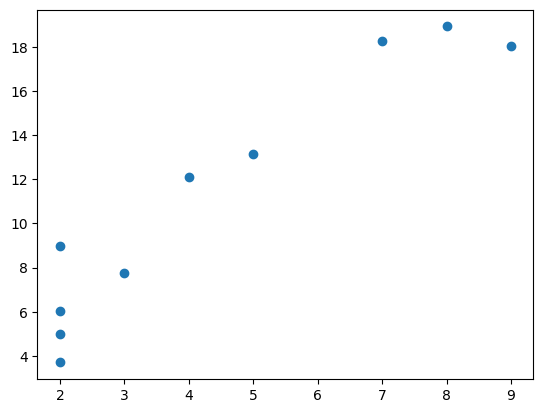

In [ ]:
plt.scatter(X, y)
plt.show()

## Solução Analítica

In [ ]:
# Cálcular Médias
X_media = np.mean(X)
y_media = np.mean(y)

# Calcular w
w = np.sum((X - X_media) * (y - y_media)) / np.sum((X - X_media) ** 2)

# Calcular b
b = b = y_media - w * X_media

# Mostrar os valores calculados para w e b
print(f"w: {w}")
print(f"b: {b}")

In [ ]:
# Previsão/predição do modelo
y_pred = w * X + b

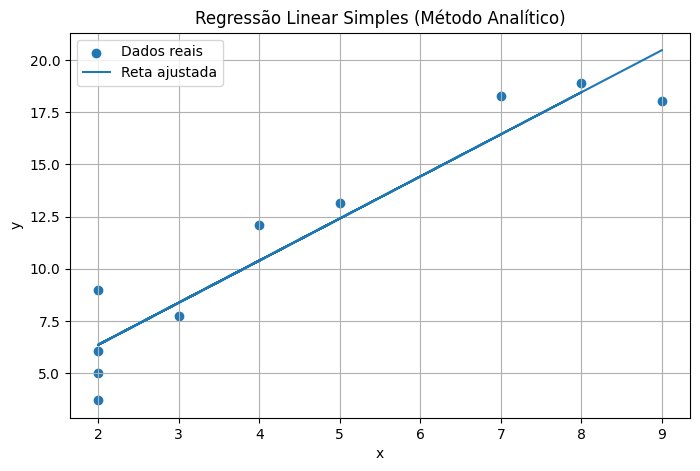

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, label="Reta ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples (Método Analítico)")
plt.legend()
plt.grid(True)
plt.show()

## Solução Numérica

In [ ]:
# Inicializa os coeficientes w e b
w = 0.0
b = 0.0

# Define uma taxa de aprendizado
alpha = 0.01

# Define número de épocas de treinamento
epocas = 1000

# Número de amostras (registros em X)
n = len(X)

# Para cada época repita os seguintes passos:
# calcular o y_pred
# calcular a função de custo
# calcular a derivada do custo em relação a w
# calcular a derivada do custo em relação a b
# ajustar os valores de w e b
for epoca in range(epocas):
    # Predição do modelo
    y_pred = w * X + b

    # Derivadas (regra da cadeia)
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # Ajusta o w e o b (descida do gradiente)
    w = w - alpha * dw
    b = b - alpha * db

    custo = np.mean((y - y_pred) ** 2)
    print(f"Custo: {custo} época: {epoca}")

# Mostrar os valores calculados para w e b
print(f"w: {w}")
print(f"b: {b}")

In [ ]:
# Previsão/predição do modelo
y_pred = w * X + b

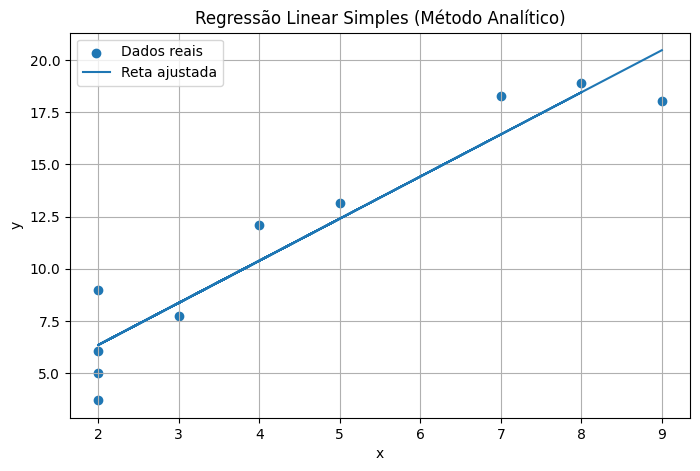

In [ ]:
# Mostrar gráfico
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, label="Reta ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples (Método Analítico)")
plt.legend()
plt.grid(True)
plt.show()

# Exemplo (com o uso de biblioteca) - Números aleatórios

In [ ]:
from sklearn.linear_model import LinearRegression

# Instanciação do modelo
lr = LinearRegression()

# Previsão/predição do modelo
lr.fit(X.reshape(-1, 1), y)

# Mostrar os valores calculados para w e b
print(f"w: {lr.coef_}")
print(f"b: {lr.intercept_}")

In [ ]:
# Previsão/predição do modelo
y_pred = lr.predict(X.reshape(-1, 1))

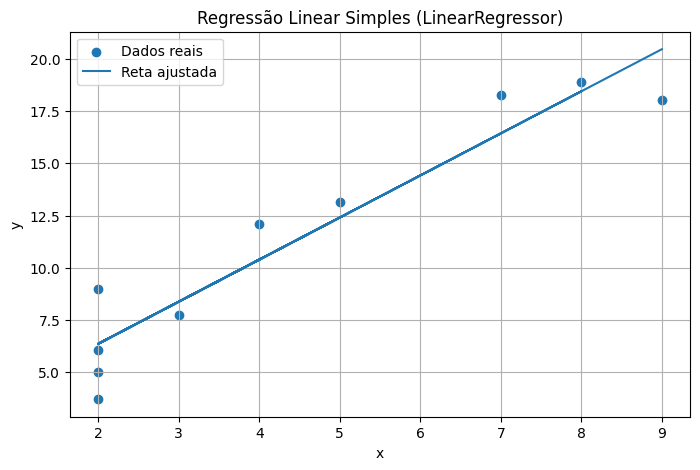

In [ ]:
# Mostrar gráfico
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, label="Reta ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples (LinearRegressor)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import SGDRegressor

# Instanciação do modelo
lr = SGDRegressor()

# Previsão/predição do modelo
lr.fit(X.reshape(-1, 1), y)

# Mostrar os valores calculados para w e b
print(f"w: {lr.coef_}")
print(f"b: {lr.intercept_}")

In [ ]:
# Previsão/predição do modelo
y_pred = lr.predict(X.reshape(-1, 1))

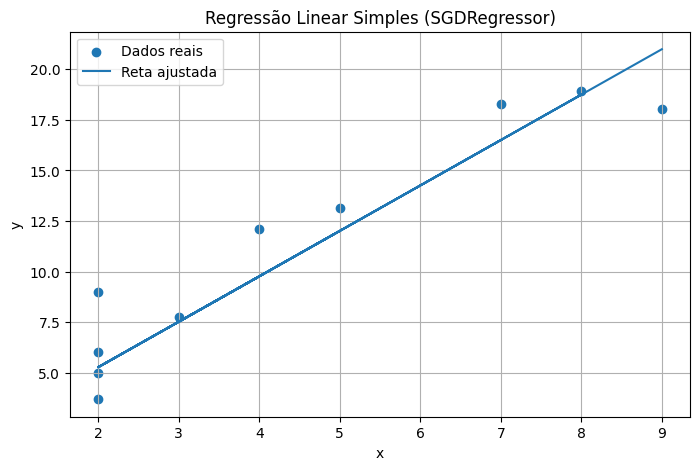

In [ ]:
# Mostrar gráfico
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Dados reais")
plt.plot(X, y_pred, label="Reta ajustada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples (SGDRegressor)")
plt.legend()
plt.grid(True)
plt.show()

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.